# Alaska: point source vs finite fault travel times

Comparison of first-arrival tsunami travel time maps for a hypothetical
rupture on the Alaska-Aleutian subduction zone computed two ways:

- **Point source** — a single origin at the centroid of the rupture area,
  fanned with rays in all directions.
- **Finite fault** — the rupture area is discretised into a grid of
  sub-sources; each sub-source fans its own rays and the minimum travel
  time across all sub-sources is taken at every grid point.

**Bathymetry:** GEBCO-derived 4 arc-minute grid (`data/NE_pacific_4arcmin.nc`),
covering 180–260°E / 10–65°N (plotted here as 180–100°W).

> **Note:** this notebook requires `scipy` and `netCDF4` in addition to the
> core TsunamiTrace dependencies.  Install with
> `pip install -e ".[examples]"`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import TsunamiTrace as tt
%matplotlib inline

## Load bathymetry

The NetCDF file stores longitudes in the 0–360° convention (180–260°E for
this domain).  We shift them to the more familiar –180 to –100°W range
for plotting; the shifted array is passed to `trace_rays` as well since
the ray integrator only requires the grid to be uniformly spaced and
ascending.

In [2]:
print('Loading data/NE_pacific_4arcmin.nc ...', end='', flush=True)
lon_arr, lat_arr, depth_tracing = tt.load_bathymetry('../data/NE_pacific_4arcmin.nc')
print(' done.')

n_lon, n_lat = depth_tracing.shape
print(f'Grid    : {n_lon} x {n_lat}  (spacing {lon_arr[1]-lon_arr[0]:.4f} deg)')
print(f'Lon     : {lon_arr[0]:.2f} to {lon_arr[-1]:.2f} deg E')
print(f'Lat     : {lat_arr[0]:.2f} to {lat_arr[-1]:.2f} deg N')
print(f'Depth   : {depth_tracing[depth_tracing>0].min():.0f} to {depth_tracing.max():.0f} m ocean')

# Shift longitudes to -180/180 convention for plotting and ray tracing
lon_arr  = lon_arr - 360.0          # 180-260 E  ->  -180 to -100 W

# depth_grid for plotting: (n_lat, n_lon), geographic sign (negative = ocean)
depth_grid = -depth_tracing.T

print(f'Lon (W) : {lon_arr[0]:.2f} to {lon_arr[-1]:.2f} deg')

Loading data/NE_pacific_4arcmin.nc ... done.
Grid    : 1200 x 825  (spacing 0.0667 deg)
Lon     : 180.03 to 259.97 deg E
Lat     : 10.03 to 64.97 deg N
Depth   : 0 to 7720 m ocean
Lon (W) : -179.97 to -100.03 deg


## Bathymetry and topography, quick plot to check all is good

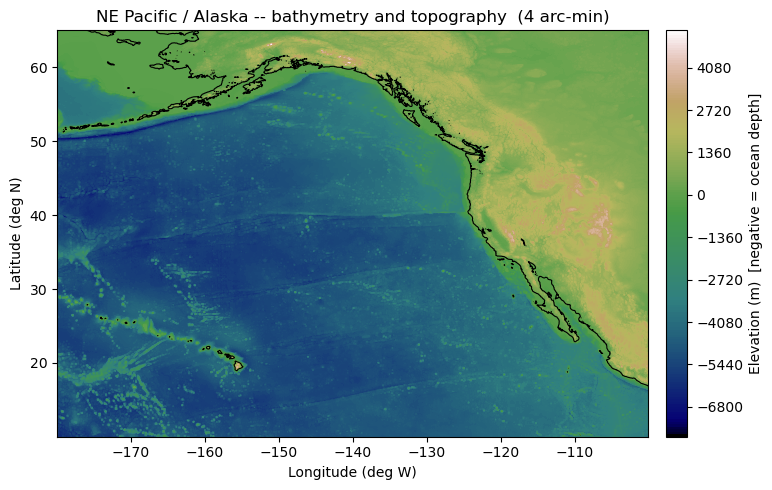

In [6]:
vmin = float(np.nanmin(depth_grid))
vmax = float(np.nanmax(depth_grid))
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))

fig, ax = plt.subplots(figsize=(10, 5))

cf = ax.contourf(lon_arr, lat_arr, depth_grid,
                 levels=200, cmap='gist_earth', norm=norm)

# Coastline at sea level
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

ax.set_xlabel('Longitude (deg W)')
ax.set_ylabel('Latitude (deg N)')
ax.set_title('NE Pacific / Alaska -- bathymetry and topography  (4 arc-min)')
ax.set_aspect('equal')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Elevation (m)  [negative = ocean depth]')
plt.tight_layout()
plt.show()

## Tsunami ray tracing

As in the Cascadia example we fan rays at a small azimuth spacing from the source. We are looking at longer trans-oceanic propagation so now we integrate for 12 hours.

The epicenter of the 1964 earthquake was onshore, we nudge it offshore for this example

In [7]:
# 1964 Alaska earthquake epicenter, nudged offshor
SOURCE_LON = -146.680926
SOURCE_LAT =  60.070651


#Ray tracing parameters
DT           =  180.0                        # integration time step, seconds
MAX_TIME     = 12 * 3600.0                    # maximum integration time, seconds
DELTA_DEG = 1e-3
AZIMUTHS_DEG = np.arange(0, 360, DELTA_DEG, dtype=float)

print(f'Source   : {SOURCE_LON}°E, {SOURCE_LAT}°N')
print(f'Rays     : {len(AZIMUTHS_DEG)}  (every {AZIMUTHS_DEG[1]-AZIMUTHS_DEG[0]:.3f}°)')
print(f'dt       : {DT:.0f} s    max time : {MAX_TIME/3600:.0f} h')
print(f'Tracing …', end='', flush=True)

ray_lon, ray_lat, _ = tt.trace_rays(
    lon_arr, lat_arr, depth_tracing,
    DT, MAX_TIME,
    SOURCE_LON, SOURCE_LAT,
    AZIMUTHS_DEG,
)

n_done = int(np.sum(~np.isnan(ray_lon[:, -1])))
print(f'  done.  {n_done}/{len(AZIMUTHS_DEG)} rays reached max_time.')

Source   : -147.3389°E, 60.9079°N
Rays     : 360000  (every 0.001°)
dt       : 180 s    max time : 12 h
Tracing …  done.  0/360000 rays reached max_time.


## Map of all the rays to check ray tracing was successful

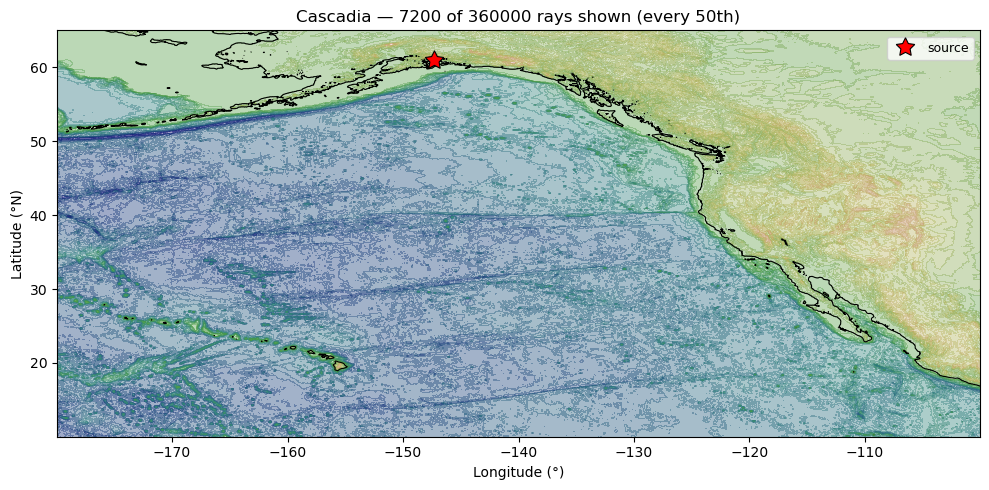

In [10]:
PLOT_EVERY_N = 50   # plot every Nth ray — increase to declutter, 1 = all rays

fig, ax = plt.subplots(figsize=(10, 5))

# Muted bathymetry background
ax.contourf(lon_arr, lat_arr, depth_grid,
            levels=50, cmap='gist_earth', norm=norm, alpha=0.4)
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Ray paths (decimated)
for i in range(0, ray_lon.shape[0], PLOT_EVERY_N):
    ax.plot(ray_lon[i], ray_lat[i], color='black', linewidth=0.4, alpha=1)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Alaska 1964 — {ray_lon.shape[0] // PLOT_EVERY_N} of {ray_lon.shape[0]} rays shown '
    f'(every {PLOT_EVERY_N}th)'
)
ax.set_xlim([lon_arr.min(),lon_arr.max()])
ax.set_ylim([lat_arr.min(),lat_arr.max()])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()